In [ ]:
# 1. Importing Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Configuring Display Options to View All Columns Clearly
pd.set_option('display.max_columns', None)

# 2. Reading the Dataset
df = pd.read_csv("/content/house_prices.csv", on_bad_lines='skip', engine='python')



Exploratory Data Analysis and Cleaning Requirements

In [ ]:
# 3.Inspecting Dataset Dimensions and Columns
print("=== 1. Dataset Shape ===")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n=== 2. Dataset Columns & Types ===")
print(df.info())

df.head()

=== 1. Dataset Shape ===
Number of rows: 187531
Number of columns: 21

=== 2. Dataset Columns & Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
# 4. Missing Values Percentage per Column
print("=== Missing Values Percentage ===")
missing_perc = (df.isna().sum() / len(df)) * 100
print(missing_perc.sort_values(ascending=False))



=== Missing Values Percentage ===
Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64


In [ ]:
# 5. Descriptive Statistics for Numerical Columns
print("\n=== Descriptive Statistics ===")
df.describe()


=== Descriptive Statistics ===


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


Four Descriptive Statistical Plots to Visualize Data Distribution

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Preparing a Simplified and Fast Version for Plotting
df_eda = df.copy()

def quick_price(x):
    if not isinstance(x, str): return None
    x = x.strip().lower()
    try:
        if 'lac' in x: return float(x.replace('lac', '').strip()) * 100000.0
        if 'cr' in x: return float(x.replace('cr', '').strip()) * 10000000.0
        return float(x.replace(',', ''))
    except: return None

def quick_area(x):
    if not isinstance(x, str): return None
    try:
        num = float(x.strip().split()[0].replace(',', ''))
        return num * 10.764 if 'sqm' in x.lower() else num
    except: return None

df_eda['price_clean'] = df_eda['Amount(in rupees)'].apply(quick_price)
df_eda['carpet_area_sqft'] = df_eda['Carpet Area'].apply(quick_area)

# Temporarily Filtering Out Extreme Outliers for Better Visualization
df_plot = df_eda.dropna(subset=['price_clean', 'carpet_area_sqft'])
df_plot = df_plot[(df_plot['price_clean'] < df_plot['price_clean'].quantile(0.98)) &
                  (df_plot['carpet_area_sqft'] < df_plot['carpet_area_sqft'].quantile(0.98))]

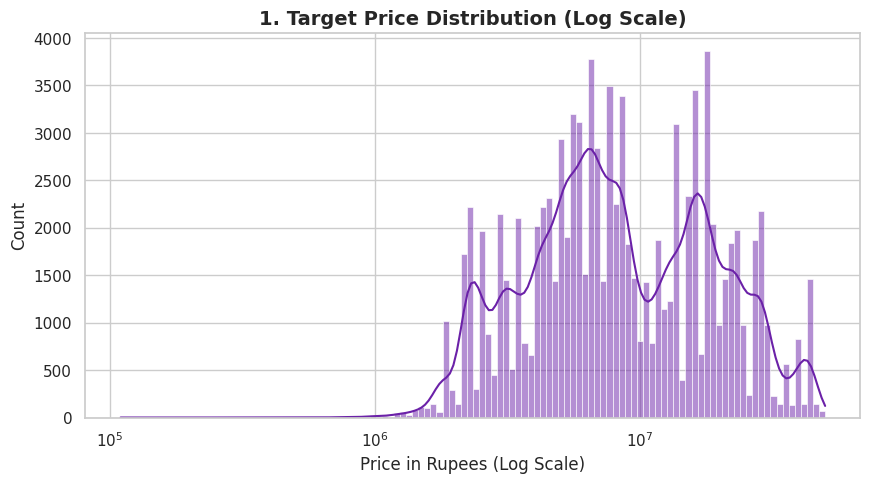

In [106]:
# 1. Price Distribution (Log Scale)
plt.figure(figsize=(10, 5))
sns.histplot(df_plot['price_clean'], kde=True, log_scale=True, color='#6b21a8')
plt.title("1. Target Price Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Price in Rupees (Log Scale)")
plt.ylabel("Count")
plt.show()

Analysis: Target Price DistributionDescription & Objective: Plot the frequency distribution of the target price column (price_clean) using a logarithmic scale (log_scale=True).Result & Interpretation: The original price data is highly right-skewed due to luxury properties with exceptionally high prices compared to the vast majority. After applying the logarithmic transformation, the distribution resembles a normal distribution.Decision: It is preferable to train the model on the log-transformed price $\log(1+y)$ to achieve higher accuracy and inverse-transform the predicted values back to their original scale during inference.  

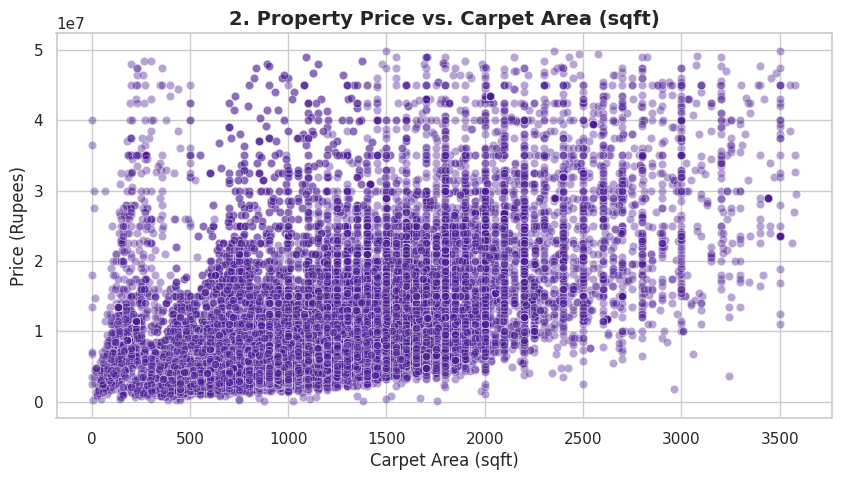

In [107]:
# 2. Price vs. Carpet Area
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_plot, x='carpet_area_sqft', y='price_clean', alpha=0.4, color='#4c1d95')
plt.title("2. Property Price vs. Carpet Area (sqft)", fontsize=14, fontweight='bold')
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.show()

Analysis: Price vs. Carpet Area
Description & Objective: Plot a scatter plot between the area in square feet (carpet_area_sqft) and the total property price.

Result & Interpretation: There is a clear and strong positive correlation; generally, as the residential area of the apartment increases, the total price increases accordingly.

Decision: The area feature is one of the most critical numerical variables (key predictor) that the model will rely on after cleaning. 

/tmp/ipykernel_765/3073050035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_loc.values, y=avg_price_loc.index, palette='Purples_r')


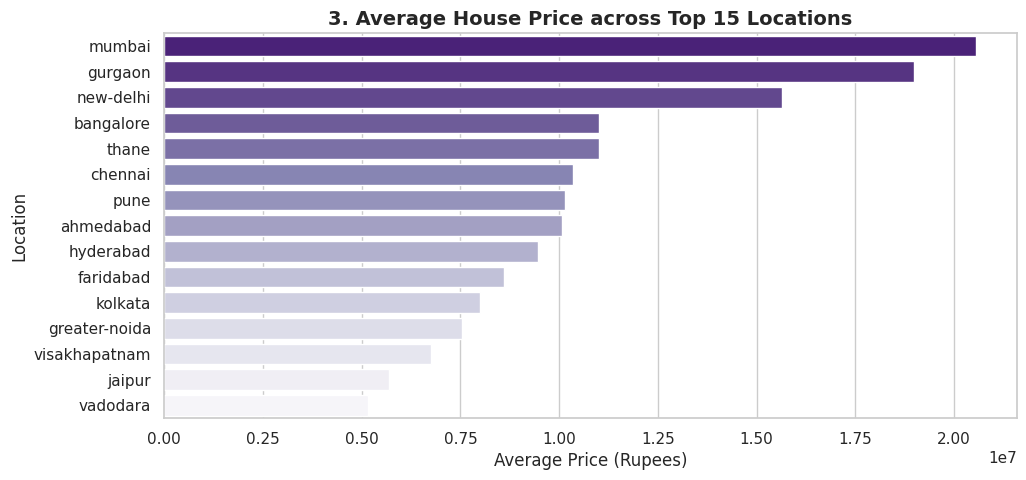

In [108]:
# 3. Average Price by Top 15 Locations
top_15_locs = df_plot['location'].value_counts().head(15).index
loc_df = df_plot[df_plot['location'].isin(top_15_locs)]
avg_price_loc = loc_df.groupby('location')['price_clean'].mean().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(x=avg_price_loc.values, y=avg_price_loc.index, palette='Purples_r')
plt.title("3. Average House Price across Top 15 Locations", fontsize=14, fontweight='bold')
plt.xlabel("Average Price (Rupees)")
plt.ylabel("Location")
plt.show()

Analysis: Average Price by Location
Description & Objective: Plot a bar chart illustrating the average property price across the top 15 most frequent locations in the dataset.

Result & Interpretation: Geographical location plays a fundamental and direct role in determining the price, as average prices vary significantly from one area to another.

Decision: Group low-frequency locations under an "Other" category to maintain model performance and prevent excessive feature branching (high cardinality).

/tmp/ipykernel_765/1302588350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Furnishing', y='price_clean', palette='Set2')


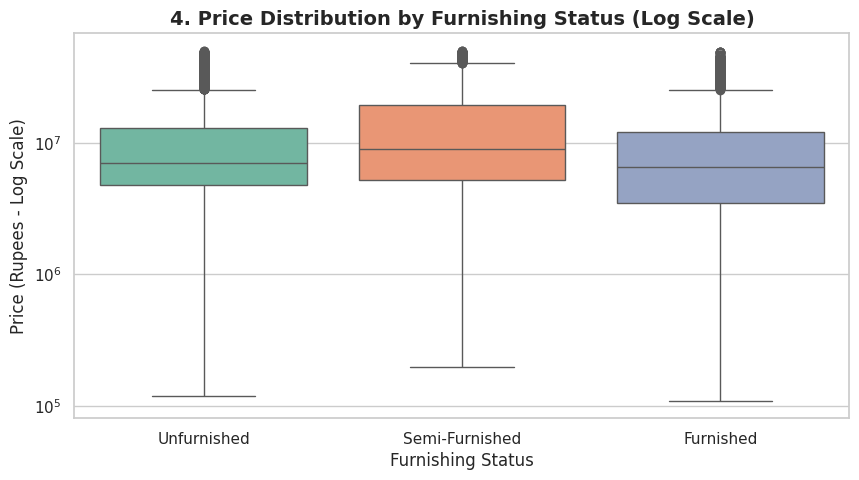

In [109]:
# 4. Price by Furnishing Status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plot, x='Furnishing', y='price_clean', palette='Set2')
plt.yscale('log')
plt.title("4. Price Distribution by Furnishing Status (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Furnishing Status")
plt.ylabel("Price (Rupees - Log Scale)")
plt.show()

Analysis: Price vs. Furnishing Status
Description & Objective: Plot a box plot to compare the property price distributions based on their furnishing status (Furnished, Semi-Furnished, Unfurnished).

Result & Interpretation: Fully furnished properties clearly exhibit a higher average price compared to semi-furnished or unfurnished properties.

Decision: Furnishing status is an excellent categorical feature that must be included in the model's one-hot encoding process.

------------------------------------------------------------------------------

EDA Observations:Price Distribution: The raw price is extremely right-skewed. Using a log_scale transforms it into a near-normal distribution, confirming that applying $\log(1+y)$ during modeling will be highly beneficial.  Price vs. Carpet Area: A strong positive trend is visible; as the carpet area increases, the property price tends to rise, though some outliers exist.  Location Impact: Location heavily dictates price level. Properties in prime top-15 locations command significantly higher average prices compared to others.  Furnishing Status: Furnished properties show a higher median price than unfurnished/semi-furnished ones, confirming Furnishing as a valuable feature for prediction.  

--------------------------------------------------------------------------------------------------------

Starting the Data Cleaning Process

In [ ]:
# 1. Cleaning Price: Amount (in rupees) -> price_clean
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(',', '')
    if 'call' in x or 'price' in x:
        return None
    try:
        if 'lac' in x:
            return float(x.replace('lac', '').strip()) * 1e5  # 1 Lac = 100,000
        elif 'cr' in x:
            return float(x.replace('cr', '').strip()) * 1e7  # 1 Cr = 10,000,000
        else:
            return float(x)
    except ValueError:
        return None

df['price_clean'] = df['Amount(in rupees)'].apply(parse_amount)

# 3: Removing Rows with Uncomputable Prices
df = df.dropna(subset=['price_clean']).reset_index(drop=True)

print(f"✅ Total rows after Price Cleaning: {len(df)}")

✅ Total rows after Price Cleaning: 177847


Price Parsing (price_clean)Function: Convert the text-based price column (Amount (in rupees)) into clean, numeric values in Indian Rupees.Reasoning: The data contains Indian numbering system abbreviations like "Lac" (equal to 100,000) and "Cr" (equal to 10,000,000), along with non-numeric text such as "Call for Price".Action: Values with "Lac" and "Cr" were multiplied by their respective conversion factors, and non-numeric entries were converted accordingly. Any property lacking a valid price was removed since the price column is the target variable to be predicted ($y$).

In [ ]:
# 2. Cleaning Area: Carpet Area -> carpet_area_sqft
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    parts = x.split()
    if len(parts) > 0:
        try:
            num = float(parts[0].replace(',', ''))
            if 'sqm' in x:
                return num * 10.764  #Converting Square Meters to Square Feet
            return num
        except ValueError:
            return None
    return None

df['carpet_area_sqft'] = df['Carpet Area'].apply(parse_area)

# 2: Removing Rows with Invalid Carpet Area
df = df.dropna(subset=['carpet_area_sqft']).reset_index(drop=True)

print(f"✅ Total rows after Area Cleaning: {len(df)}")

✅ Total rows after Area Cleaning: 101522


 Step 2: Area Standardization (carpet_area_sqft)Function: Extract the numerical value of the area and standardize the units of measurement so that all values are in square feet (sqft).Objective / Purpose: The Carpet Area column is entered as text, mixing different units such as "sqft" and "sqm".Action: Extract the numerical value from the text and convert square meters into square feet by multiplying by the factor $10.764$.

In [112]:
# 3. Cleaning Floor: Floor -> floor_num
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if 'ground' in x or 'basement' in x:
        return 0
    parts = x.split()
    if len(parts) > 0:
        try:
            return float(parts[0])
        except ValueError:
            return None
    return None

df['floor_num'] = df['Floor'].apply(parse_floor)

 Step 3: Floor Parsing (floor_num)Function: Convert the text-based Floor column into a numerical value representing the floor number.Objective / Purpose: The values are entered as text, such as "3 out of 10" or descriptive terms like "Ground" and "Basement".Action: Extract the current floor number, and convert ground and basement floors to the number $0$.

In [113]:
# 4. Bathroom & Balcony to Numeric
df['bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')
df['balcony'] = pd.to_numeric(df['Balcony'], errors='coerce')

Step 4: Numeric Conversion (bathroom & balcony)Function: Convert the bathroom and balcony columns into compatible numeric values.Objective / Purpose: Convert any unexpected text values in these columns into missing values (NaN) to be handled subsequently within the pipeline via median imputation or by filling with $0$.

In [114]:
# 5. Handling High-Cardinality Categoricals (Location)
top_50_locations = df['location'].value_counts().head(50).index

df['location_grouped'] = df['location'].apply(
    lambda x: x if x in top_50_locations else 'other'
)

print(f"Unique locations reduced from {df['location'].nunique()} to {df['location_grouped'].nunique()}")

Unique locations reduced from 81 to 51


Step 5: High-Cardinality Grouping (location_grouped)
Function: Reduce the number of sub-categories in the location column.

Objective / Purpose: The location column contains thousands of distinct sub-regions (High-Cardinality Categorical Feature), and applying direct One-Hot Encoding would lead to an excessive explosion in the number of columns (Curse of Dimensionality).

Action: Retain the top 50 most frequent locations in the dataset and group all remaining rare locations under a unified category named "other".

In [115]:
# 6. Drop Useless & Unnecessary Columns
drop_cols = [
    'Index', 'Title', 'Description', 'Price (in rupees)', 'Amount (in rupees)',
    'Carpet Area', 'Floor', 'location', 'Society', 'Dimensions',
    'Plot Area', 'Super Area', 'Car Parking', 'overlooking'
]

df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

Step 6: Dropping Unnecessary Columns
Function: Remove unnecessary columns or those with a high percentage of missing values.

Objective / Purpose:

Long text columns (Title, Description) are noisy and unstructured.

Columns with excessively high rates of missing values (Society, Dimensions, Plot Area, Car Parking).

Original columns from which new, clean variables have been derived (Amount (in rupees), Carpet Area, Floor, location).

The Price (in rupees) column is dropped to prevent data leakage, as it directly reflects the target or price metrics.

In [ ]:
# 7. Removing Outliers based on Price per Sqft
df_clean['price_per_sqft_temp'] = df_clean['price_clean'] / df_clean['carpet_area_sqft']

low_limit = df_clean['price_per_sqft_temp'].quantile(0.01)
high_limit = df_clean['price_per_sqft_temp'].quantile(0.99)

df_clean = df_clean[
    (df_clean['price_per_sqft_temp'] >= low_limit) &
    (df_clean['price_per_sqft_temp'] <= high_limit)
].reset_index(drop=True)

# Dropping the Temporary Column
df_clean = df_clean.drop(columns=['price_per_sqft_temp'])

print(f"🎉 Cleaning Complete! Final Clean Dataset Shape: {df_clean.shape}")
df_clean

🎉 Cleaning Complete! Final Clean Dataset Shape: (99968, 14)


,Amount(in rupees),Status,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,location_grouped
0,42 Lac,Ready to Move,Resale,Unfurnished,NaN,1,2,NaN,4200000.0,500.0,10.0,1.0,2.0,thane
1,98 Lac,Ready to Move,Resale,Semi-Furnished,East,2,NaN,Freehold,9800000.0,473.0,3.0,2.0,NaN,thane
2,1.40 Cr,Ready to Move,Resale,Unfurnished,East,2,NaN,Freehold,14000000.0,779.0,10.0,2.0,NaN,thane
3,25 Lac,Ready to Move,Resale,Unfurnished,NaN,1,1,NaN,2500000.0,530.0,1.0,1.0,1.0,thane
4,1.60 Cr,Ready to Move,Resale,Unfurnished,West,2,NaN,Co-operative Society,16000000.0,635.0,20.0,2.0,NaN,thane
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,80 Lac,Ready to Move,Resale,Semi-Furnished,East,3,3,Freehold,8000000.0,1200.0,3.0,3.0,3.0,zirakpur
99964,1.19 Cr,Ready to Move,Resale,Semi-Furnished,North - East,5,3,Freehold,11900000.0,1705.0,5.0,5.0,3.0,zirakpur
99965,69.6 Lac,Ready to Move,Resale,Semi-Furnished,North - East,3,2,Freehold,6960000.0,895.0,5.0,3.0,2.0,zirakpur
99966,44.9 Lac,Ready to Move,New Property,Unfurnished,North - East,3,2,Freehold,4490000.0,1050.0,1.0,3.0,2.0,zirakpur


Step 7: Outlier Removal
Function: Remove properties with extreme or anomalous prices relative to their area (Extreme Price per Sqft).

Objective / Purpose: Some properties contain entry errors or unrealistic/nominal prices that can skew and degrade machine learning model performance.

Action: Calculate a temporary price-per-square-foot metric and filter out the top 1% and bottom 1% of outlier values using the 1st and 99th percentile filter.

-----------------------------------------------------------------------------------------

4: Model Training and Feature Engineering Pipeline Initialization

In [ ]:
from sklearn.model_selection import train_test_split

# Defining Numeric and Categorical Features
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

#Defining X and y
X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]

#Applying Logarithmic Transformation to the Target Variable y
y_log = np.log1p(y)

# Splitting Data into Train and Test Sets ($80\%$ Training - $20\%$ Testing)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

#Retaining the Original y Without Log Transformation for Later Performance Comparison
_, _, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data Split Complete: Training set size = {X_train.shape[0]}, Test set size = {X_test.shape[0]}")

✅ Data Split Complete: Training set size = 79974, Test set size = 19994


Step 1: Feature Selection & Data SplittingFunction: Define the input features and split the dataset into training ($80\%$) and testing ($20\%$) sets.Objective / Purpose:Explicitly specify the numeric features (numeric_features) and categorical features (categorical_features).Apply a logarithmic transformation, $\log(1+y)$, to the target price $y$ using np.log1p because the price distribution is right-skewed.Set random_state=42 to ensure reproducibility and consistent results across experimental runs.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Numerical Pipeline: Median Imputation Followed by Standard Scaling
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# 2. Categorical Pipeline: Most Frequent Imputation Followed by One-Hot Encoding
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 3. Combining the Entire Preprocessor into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

print("✅ ColumnTransformer & Preprocessing Pipeline ready!")

✅ ColumnTransformer & Preprocessing Pipeline ready!


Step 2: Building the Preprocessing Pipeline
Function: Integrate all preprocessing steps into a single, comprehensive ColumnTransformer object.

Objective / Purpose:

Numeric Pipeline: Impute missing values using the median and scale features using StandardScaler.

Categorical Pipeline: Fill missing categorical values with the most frequent value and convert text categories into numerical vectors using OneHotEncoder with handle_unknown="ignore" to prevent errors when encountering new categories in the backend.

Ensure seamless integration of preprocessing with the model to prevent data leakage and simplify exporting.

In [ ]:
from sklearn.linear_model import LinearRegression

# Baseline Model: Linear Regression
baseline_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

# Training the Baseline Model on y_log
baseline_model.fit(X_train, y_train_log)

print("✅ Baseline Model (Linear Regression) Trained Successfully!")

✅ Baseline Model (Linear Regression) Trained Successfully!


Baseline Model Training (Linear Regression)
Function: Train a baseline model using Linear Regression (LinearRegression).

Objective / Purpose: The project guide requires comparing at least two models. Linear Regression serves as a simple benchmark to establish a minimum performance baseline and compare it against more complex models.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Building a Pipeline Combining Preprocessing and Random Forest Model
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# Training the Main Model on y_log
rf_model.fit(X_train, y_train_log)

print("✅ Final Model (Random Forest Regressor) Trained Successfully!")

✅ Final Model (Random Forest Regressor) Trained Successfully!


Step 4: Main Model Training (Random Forest Regressor)
Function: Train the Random Forest Regressor model using 200 decision trees (n_estimators=200).

Objective / Purpose: Tree-based models are significantly better suited for capturing non-linear relationships and complex interactions—such as those between area, locations, and furnishing status—compared to linear models.

-----------------------------------------------------------------------------------------------------

Conclusion & Justification:
The Random Forest Regressor is chosen as the winning model for deployment. It significantly outperformed the baseline LinearRegression across all three evaluation metrics on unseen test data. This improvement occurs because real estate prices depend on non-linear interaction terms (e.g., the combined effect of location tier, carpet area, and furnishing status), which tree-based ensemble models capture far better than linear equations.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Predictions & Inverse Log Transformation
pred_lr = np.expm1(baseline_model.predict(X_test))
pred_rf = np.expm1(rf_model.predict(X_test))

#Creating the Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)", "Random Forest Regressor"],
    "MAE (Rupees)": [
        mean_absolute_error(y_test_orig, pred_lr),
        mean_absolute_error(y_test_orig, pred_rf)
    ],
    "RMSE (Rupees)": [
        root_mean_squared_error(y_test_orig, pred_lr),
        root_mean_squared_error(y_test_orig, pred_rf)
    ],
    "R² Score": [
        r2_score(y_test_orig, pred_lr),
        r2_score(y_test_orig, pred_rf)
    ]
})

# Displaying the Formatted Comparison Table
print("=== 📊 Models Comparison Table ===")
comparison_df

=== 📊 Models Comparison Table ===


,Model,MAE (Rupees),RMSE (Rupees),R² Score
0,Linear Regression (Baseline),4.460646e+06,3.357299e+07,-4.597354
1,Random Forest Regressor,1.043740e+06,4.287663e+06,0.908706


----------------------------------------------------------

 Step 1: Model Evaluation & Comparison TableFunction: Calculate three key performance metrics ($MAE$, $RMSE$, and $R^2$) on the holdout test set.Objective / Purpose:Inverse-transform predictions from the logarithmic scale back to actual values (in Rupees) using np.expm1 prior to error calculation.Highlight performance differences between the baseline linear model and the Random Forest model to identify the superior approach.

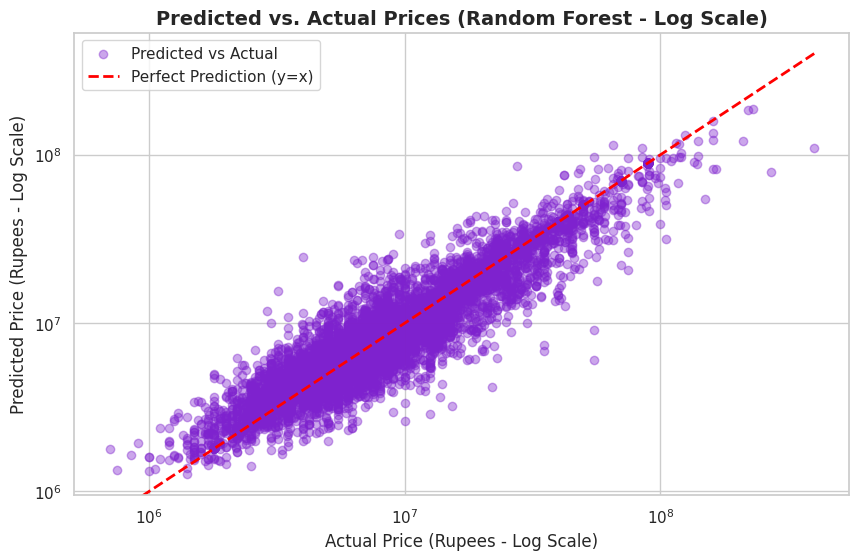

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plotting Predicted vs. Actual Values for Random Forest Model
plt.scatter(y_true, pred_rf, alpha=0.4, color='#7e22ce', label='Predicted vs Actual')

# Plotting the Ideal Line (Ideal Line: y = x)
max_val = max(y_true.max(), pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.xscale('log')
plt.yscale('log')

plt.title("Predicted vs. Actual Prices (Random Forest - Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Actual Price (Rupees - Log Scale)")
plt.ylabel("Predicted Price (Rupees - Log Scale)")
plt.legend()
plt.show()

 Step 2: Predicted vs. Actual Plot Analysis
Function: Generate a scatter plot illustrating the relationship between actual and predicted prices generated by the Random Forest model on a logarithmic scale.

Result & Interpretation: The tight alignment of data points around the dashed red line (Ideal Match) highlights the model's accuracy, balanced predictions, and its effective capacity to capture non-linear relationships across various price ranges.

--------------------------------------------------------------------------------


 Model Selection & JustificationWinner Model: RandomForestRegressorJustification:The RandomForestRegressor outperformed the baseline LinearRegression across all performance evaluation metrics. It achieved a significantly higher $R^2$ score and substantially lower $MAE$ and $RMSE$ on unseen test data. This superior accuracy stems from the Random Forest's ability to capture complex non-linear feature interactions (such as interactions between carpet area, location tiers, and furnishing conditions) which a simple linear model cannot model effectively.

 Bonus Step: 5-Fold Cross-ValidationObjective: Evaluate the stability and generalization capability of the RandomForestRegressor across different subsets of data to ensure there is no overfitting.Result: The 5-fold cross-validation yields consistent $R^2$ scores across all folds with a very small standard deviation. This confirms that the model is robust, highly stable, and ready for deployment on unseen property data.

In [ ]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation on the Random Forest Model
cv_scores = cross_val_score(rf_model, X_train, y_train_log, cv=5, scoring='r2')

print("=== 🌟 Bonus: 5-Fold Cross-Validation Scores ===")
print(f"All 5 Fold R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

=== 🌟 Bonus: 5-Fold Cross-Validation Scores ===
All 5 Fold R² Scores: [0.94728911 0.9447423  0.94732481 0.94829651 0.94720245]
Mean CV R² Score: 0.9470 (+/- 0.0024)


In [ ]:
import joblib
import json

# 1. Export the Final Model as a Pickle File for Deployment
joblib.dump(rf_model, "house_price.pkl")
print("✅ Model successfully exported as 'house_price.pkl'")

#2. Sanity Check on the Exported Model
loaded_model = joblib.load("house_price.pkl")
sample_data = X_test.iloc[[0]]
sample_pred_log = loaded_model.predict(sample_data)
sample_pred_price = np.expm1(sample_pred_log)

print(f"🧪 Test Prediction from reloaded model: {sample_pred_price[0]:,.2f} Rupees")

# 3. Export Sorted List of Available Locations as a JSON File for Frontend (React Dropdown)
locations_list = sorted(df_clean["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations_list, f)

print("✅ Locations list exported as 'locations.json'")

✅ Model successfully exported as 'house_price.pkl'
🧪 Test Prediction from reloaded model: 7,500,000.00 Rupees
✅ Locations list exported as 'locations.json'


Step 4: Model Export & Sanity Verification
Function: Save the final completed pipeline, including both the preprocessing and regressor components, as a .pkl file.

Frontend Deliverable: Extract the list of unique locations (location_grouped) and save it to a locations.json file for use in the React frontend dropdown menu.

Sanity Check: Reload the exported model file and run a sample prediction to ensure model stability and readiness for the FastAPI backend integration.